## Ideal Low Pass Filter

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# -------- Ideal Low Pass Filter Function --------
def ideal_low_pass_filter(image, D0):

    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    M, N = img.shape

    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    H = np.zeros((M, N))

    for u in range(M):
        for v in range(N):

            D = np.sqrt((u - M/2)**2 + (v - N/2)**2)

            if D <= D0:
                H[u, v] = 1
            else:
                H[u, v] = 0

    # Apply filter
    G = F_shift * H

    G_shift = np.fft.ifftshift(G)
    g = np.fft.ifft2(G_shift)
    g = np.abs(g)

    return img, g


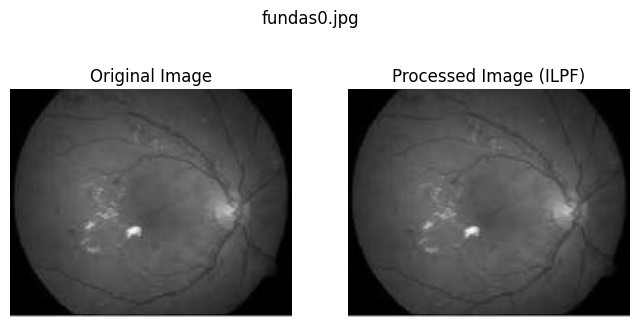

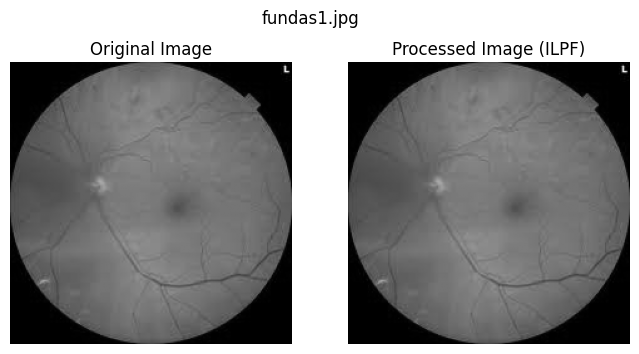

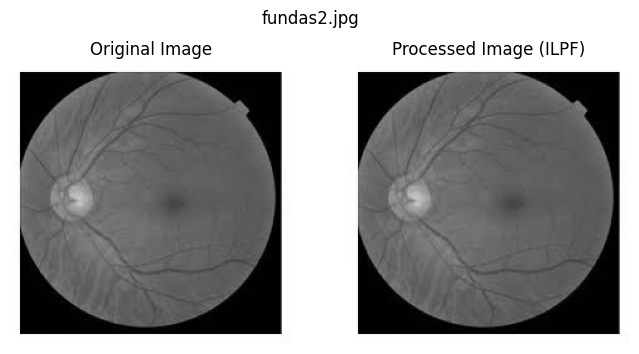

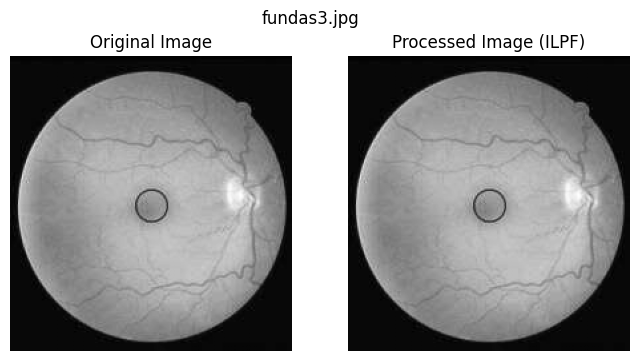

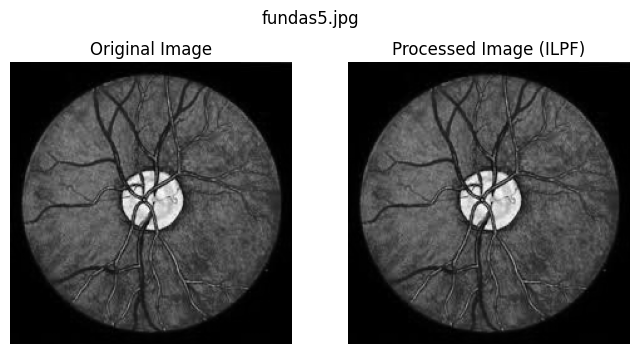

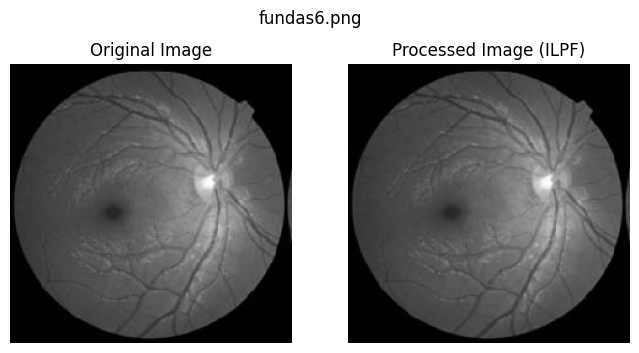

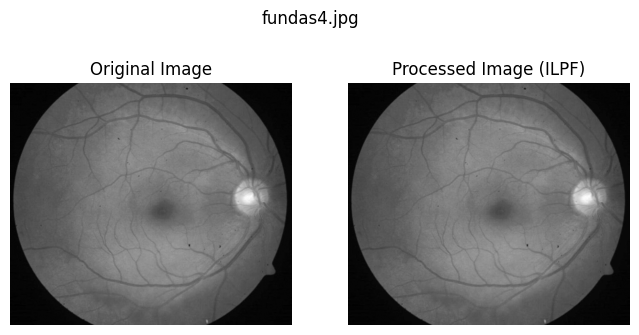

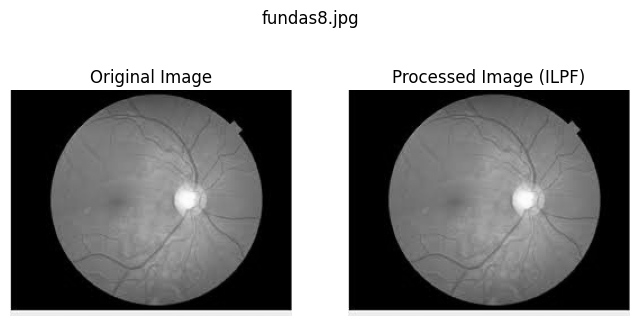

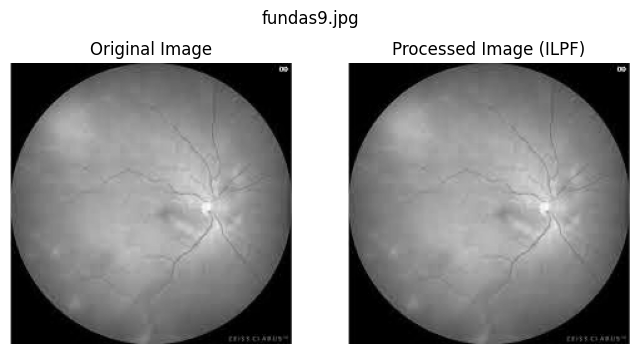

In [11]:
folder_path = r"/content/drive/MyDrive/Fundas Images"

D0 = 230


image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg','.png','.jpeg'))]

for file in image_files:

    path = os.path.join(folder_path, file)

    image = cv2.imread(path)

    original, filtered = ideal_low_pass_filter(image, D0)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Processed Image (ILPF)")
    plt.imshow(filtered, cmap='gray')
    plt.axis('off')

    plt.suptitle(file)
    plt.show()

## Ideal High pass filter

In [12]:
folder_path = '/content/drive/MyDrive/Fundas Images/'

extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Ideal High Pass Filter
def ideal_high_pass_filter(img, D0):
    M, N = img.shape

    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    H = np.zeros((M, N))

    for u in range(M):
        for v in range(N):
            D = np.sqrt((u - M/2)**2 + (v - N/2)**2)

            if D > D0:
                H[u, v] = 1
            else:
                H[u, v] = 0

    G = H * F_shift

    G_shift = np.fft.ifftshift(G)
    g = np.fft.ifft2(G_shift)

    return np.abs(g)


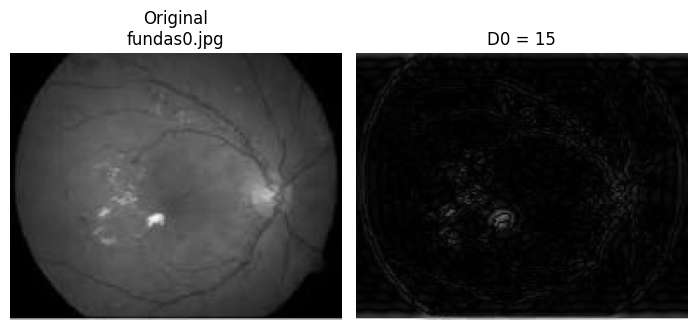

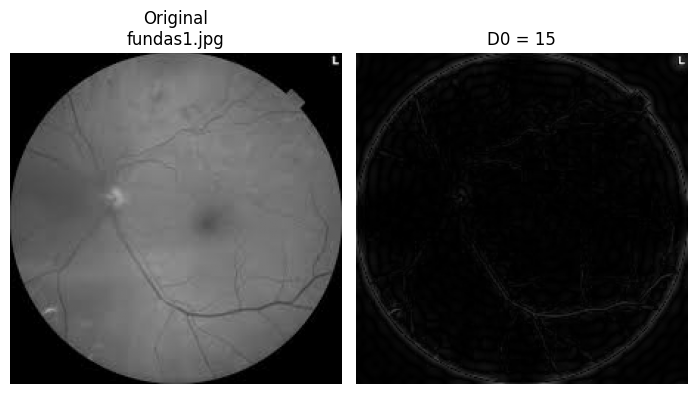

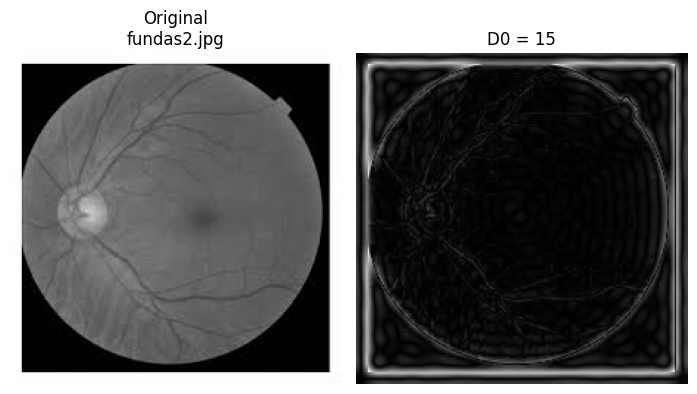

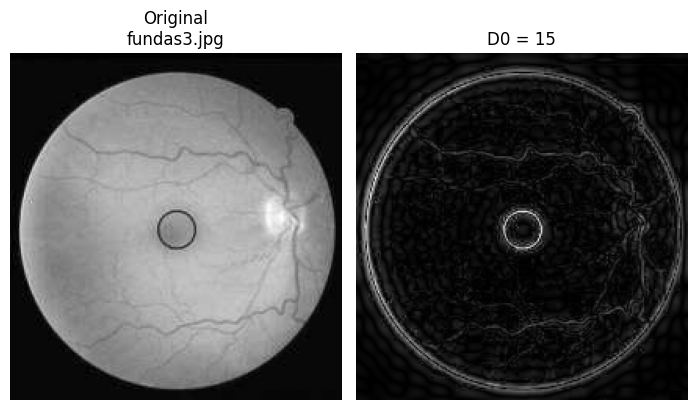

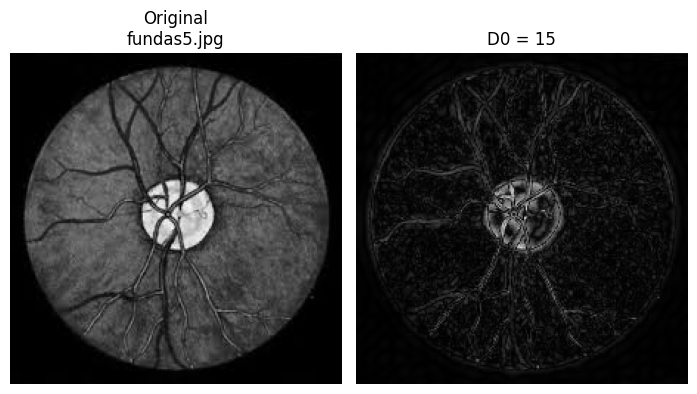

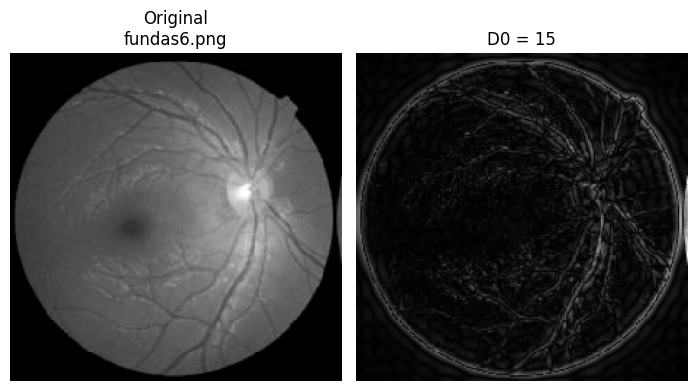

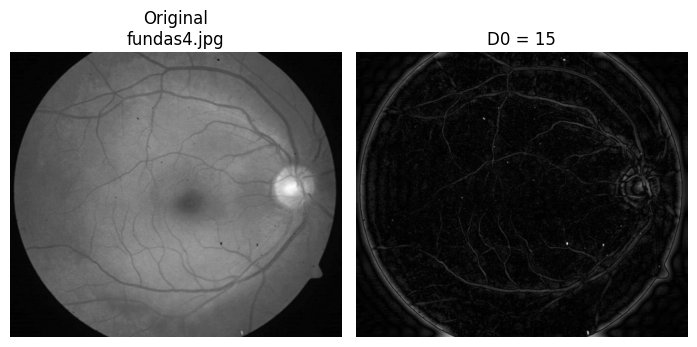

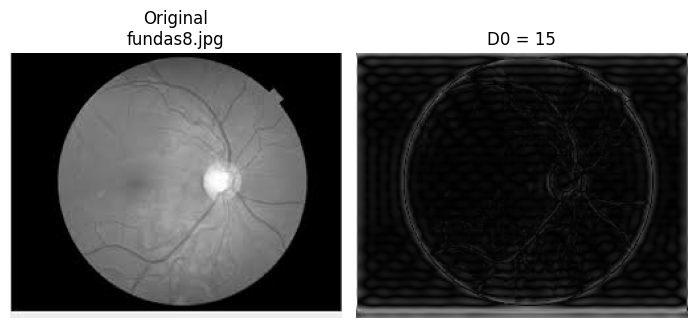

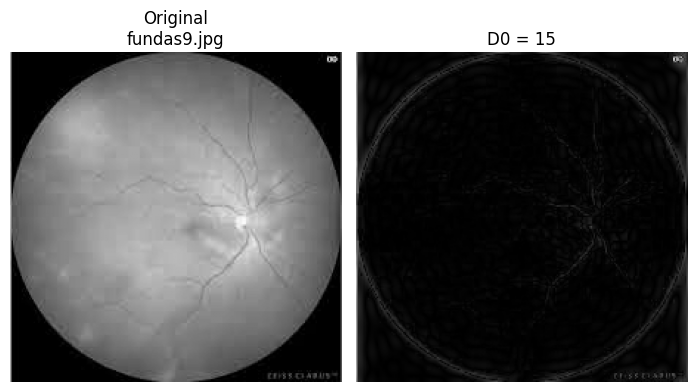

In [7]:
D0_values = [15]


image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(extensions)]

for file in image_files:
    path = os.path.join(folder_path, file)

    img = cv2.imread(path, 0)

    results = [ideal_high_pass_filter(img, d) for d in D0_values]

    plt.figure(figsize=(14,5))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Original\n{file}")
    plt.axis('off')

    for i, D0 in enumerate(D0_values):
        plt.subplot(1, 4, i+2)
        plt.imshow(results[i], cmap='gray')
        plt.title(f"D0 = {D0}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()